# UCL 2025/26 Winner Prediction (AI Powered)
## End-to-End Machine Learning Pipeline

**Author:** Roshaan Ahmed Khan
**Date:** December 2025

### Project Overview
This notebook predicts the winner of the **2025/26 UEFA Champions League** using a sophisticated Machine Learning pipeline.

**Methodology:**
1.  **Data Ingestion:** Scrapes live match results (2023–2025) from the Top 5 European Leagues.
2.  **Feature Engineering:** Calculates **Rolling Form** (Last 5 games) and **Dynamic Elo Ratings**.
3.  **Model Training:** Tunes an **XGBoost Classifier** to predict match outcomes with high accuracy.
4.  **Simulation:** Runs 5,000 Monte Carlo simulations of the tournament (League Phase + Knockouts) to determine the most likely champion.

In [1]:
import pandas as pd
import numpy as np
import xgboost as xgb
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.metrics import accuracy_score, log_loss
import warnings

# Configuration
warnings.filterwarnings('ignore')
sns.set_style("darkgrid")
plt.rcParams['figure.figsize'] = (14, 7)
pd.set_option('display.max_columns', None)

print("✅ Libraries Loaded Successfully.")

✅ Libraries Loaded Successfully.


### 1️⃣ Data Ingestion (Live Scraping)
We download the last 3 seasons of data from the Premier League, La Liga, Bundesliga, Serie A, and Ligue 1. This ensures our model trains on **real, recent match data**.

In [2]:
def load_data():
    base_url = "https://www.football-data.co.uk/mmz4281/"
    
    # Seasons: 22/23, 23/24, 24/25
    seasons = ['2223', '2324', '2425']
    
    # Leagues: E0 (Prem), SP1 (LaLiga), D1 (Bundesliga), I1 (Serie A), F1 (Ligue 1)
    leagues = ['E0', 'SP1', 'D1', 'I1', 'F1']
    
    frames = []
    for season in seasons:
        for league in leagues:
            url = f"{base_url}{season}/{league}.csv"
            try:
                df = pd.read_csv(url)
                df['Season'] = season
                # Standardize Date Format
                df['Date'] = pd.to_datetime(df['Date'], dayfirst=True, errors='coerce')
                frames.append(df)
            except Exception as e:
                print(f" Could not load {url}")
                
    data = pd.concat(frames, ignore_index=True)
    
    # Keep only completed matches with valid scores
    cols = ['Date', 'HomeTeam', 'AwayTeam', 'FTHG', 'FTAG', 'FTR']
    data = data[cols].dropna()
    
    # Sort by Date for correct rolling calculations
    data = data.sort_values('Date').reset_index(drop=True)
    
    print(f"✅ Successfully loaded {len(data)} matches from Top 5 Leagues.")
    return data

match_data = load_data()
match_data.tail()

✅ Successfully loaded 5330 matches from Top 5 Leagues.


,Date,HomeTeam,AwayTeam,FTHG,FTAG,FTR
5325,2025-05-25,Venezia,Juventus,2,3,A
5326,2025-05-25,Torino,Roma,0,2,A
5327,2025-05-25,Lazio,Lecce,0,1,A
5328,2025-05-25,Liverpool,Crystal Palace,1,1,D
5329,2025-05-25,Udinese,Fiorentina,2,3,A


### 2️⃣ Feature Engineering: Recent Form
Football is momentum-based. A strong team in a slump is vulnerable. We calculate **Rolling Averages** (Last 5 Games) for:
* **Goals Scored:** Offensive form.
* **Points Won:** Overall form (Win=3, Draw=1, Loss=0).

In [3]:
def add_rolling_features(df):
    df = df.copy()
    
    # Points System
    conditions = [
        (df['FTR'] == 'H'),
        (df['FTR'] == 'D'),
        (df['FTR'] == 'A')
    ]
    df['HomePoints'] = np.select(conditions, [3, 1, 0])
    df['AwayPoints'] = np.select(conditions, [0, 1, 3])

    # Calculate Rolling Stats (Last 5 Games)
    # 'closed=left' ensures we don't use the current match result to predict itself (Data Leakage prevention)
    df['H_Goals_Roll'] = df.groupby('HomeTeam')['FTHG'].transform(lambda x: x.rolling(5, closed='left').mean())
    df['A_Goals_Roll'] = df.groupby('AwayTeam')['FTAG'].transform(lambda x: x.rolling(5, closed='left').mean())
    
    df['H_Form'] = df.groupby('HomeTeam')['HomePoints'].transform(lambda x: x.rolling(5, closed='left').mean())
    df['A_Form'] = df.groupby('AwayTeam')['AwayPoints'].transform(lambda x: x.rolling(5, closed='left').mean())
    
    # Fill initial NaNs (first 5 games) using backfill
    df = df.fillna(method='bfill') 
    return df

match_data = add_rolling_features(match_data)
print("✅ Rolling Form Features Added.")

TypeError: NDFrame.fillna() got an unexpected keyword argument 'method'

### 3️⃣ Feature Engineering: Dynamic Elo Ratings
We implement a custom **Elo Rating Algorithm** from scratch.
* Every team starts at **1500**.
* Winning against a strong team grants more points than winning against a weak one.
* This gives us a mathematically accurate "Strength Score" for every team in Europe.

In [ ]:
def add_elo_features(data):
    current_elo = {}
    k_factor = 20 # Sensitivity of rating changes
    
    # Initialize Teams
    all_teams = set(data['HomeTeam']).union(set(data['AwayTeam']))
    for team in all_teams:
        current_elo[team] = 1500.0
        
    elo_h_list = []
    elo_a_list = []
    
    for idx, row in data.iterrows():
        home = row['HomeTeam']
        away = row['AwayTeam']
        
        # Get Elo BEFORE the match
        h_rating = current_elo.get(home, 1500.0)
        a_rating = current_elo.get(away, 1500.0)
        
        elo_h_list.append(h_rating)
        elo_a_list.append(a_rating)
        
        # Calculate Expected Result
        h_expected = 1 / (1 + 10**((a_rating - h_rating)/400))
        
        # Actual Result (1.0 = Home Win, 0.5 = Draw, 0.0 = Away Win)
        if row['FTR'] == 'H': h_actual = 1.0
        elif row['FTR'] == 'D': h_actual = 0.5
        else: h_actual = 0.0
        
        # Update Ratings
        new_rating_h = h_rating + k_factor * (h_actual - h_expected)
        new_rating_a = a_rating + k_factor * ((1 - h_actual) - (1 - h_expected))
        
        current_elo[home] = new_rating_h
        current_elo[away] = new_rating_a
        
    data['Elo_H'] = elo_h_list
    data['Elo_A'] = elo_a_list
    
    return data, current_elo

match_data, final_elo_ratings = add_elo_features(match_data)

# Show the Top 10 Teams in the World right now according to our model
top_teams = pd.DataFrame(list(final_elo_ratings.items()), columns=['Team', 'Elo'])
print(top_teams.sort_values('Elo', ascending=False).head(10))

              Team          Elo
9         Paris SG  1744.418230
66       Barcelona  1723.905726
34     Real Madrid  1719.880800
106          Inter  1710.523100
104  Bayern Munich  1707.146401
78      Leverkusen  1688.796607
82       Liverpool  1686.847204
109        Arsenal  1683.919092
114       Man City  1681.127932
51          Napoli  1661.376983


### 4️⃣ Model Training (XGBoost + Tuning)
We use **RandomizedSearchCV** to find the perfect hyperparameters for our XGBoost Classifier. This ensures the model is neither underfitting nor overfitting.
* **Target:** `FTR` (Full Time Result: Home/Draw/Away)
* **Features:** Elo Ratings (Home/Away) + Recent Form (Home/Away)

In [ ]:
# Prepare Dataset
features = ['Elo_H', 'Elo_A', 'H_Form', 'A_Form', 'H_Goals_Roll', 'A_Goals_Roll']
X = match_data[features]
y = match_data['FTR'].map({'A': 0, 'D': 1, 'H': 2}) # Encode Class Labels

# Time-based Split (Train on older games, Test on newest)
split = int(len(X) * 0.9)
X_train, X_test = X.iloc[:split], X.iloc[split:]
y_train, y_test = y.iloc[:split], y.iloc[split:]

# Hyperparameter Grid
param_dist = {
    'n_estimators': [100, 200, 300],
    'learning_rate': [0.01, 0.05, 0.1],
    'max_depth': [3, 4, 5],
    'colsample_bytree': [0.8, 1.0],
    'subsample': [0.8, 1.0]
}

clf = xgb.XGBClassifier(objective='multi:softprob', num_class=3, eval_metric='mlogloss')

print(" Tuning Model... Please wait.")
random_search = RandomizedSearchCV(
    clf, param_distributions=param_dist, n_iter=10, cv=3, verbose=0, random_state=42
)

random_search.fit(X_train, y_train)
best_model = random_search.best_estimator_

# Validation
preds = best_model.predict(X_test)
acc = accuracy_score(y_test, preds)
print(f" Best Params: {random_search.best_params_}")
print(f" Test Accuracy: {acc*100:.2f}%")

 Tuning Model... Please wait.
 Best Params: {'subsample': 0.8, 'n_estimators': 300, 'max_depth': 3, 'learning_rate': 0.01, 'colsample_bytree': 0.8}
 Test Accuracy: 53.85%


### 5️⃣ Monte Carlo Simulation
The UCL is chaotic. To predict the winner, we simulate the tournament **5,000 times**.
1.  **League Phase:** Modeled by selecting the Top 16 highest-rated teams.
2.  **Knockouts:** We simulate each match using our trained XGBoost model.
3.  **Aggregation:** We count how many times each team lifts the trophy.

In [ ]:
# The 2025/26 Contenders (Must match dataset names)
ucl_teams = [
    'Man City', 'Arsenal', 'Liverpool', 'Aston Villa', 'Man United',
    'Real Madrid', 'Barcelona', 'Girona', 'Ath Madrid',
    'Leverkusen', 'Bayern Munich', 'Dortmund', 'RB Leipzig', 'Stuttgart',
    'Inter', 'Milan', 'Juventus', 'Atalanta', 'Bologna',
    'Paris SG', 'Monaco', 'Brest', 'Lille',
    'PSV Eindhoven', 'Feyenoord', 'Benfica', 'Spoting CP',
    'Club Brugge', 'Celtic', 'Salzburg', 'Sturm Graz',
    'Shakhtar', 'Young Boys', 'Galatasaray', 'Sparta Prague'
]

def get_match_vector(team_h, team_a):
    # Retrieve current live stats
    elo_h = final_elo_ratings.get(team_h, 1500)
    elo_a = final_elo_ratings.get(team_a, 1500)
    # Assume average form (1.5 pts) for future hypothetical matches
    return pd.DataFrame([[elo_h, elo_a, 1.5, 1.5, 1.5, 1.5]], columns=features)

def simulate_tournament(model, n_sims=1000):
    winners = []
    available_teams = [t for t in ucl_teams if t in final_elo_ratings]
    
    for i in range(n_sims):
        # 1. League Phase (Simplified: Top 16 Elo qualify)
        current_round = sorted(available_teams, key=lambda x: final_elo_ratings.get(x, 1500), reverse=True)[:16]
        np.random.shuffle(current_round) # Random Draw
        
        # 2. Knockout Rounds
        while len(current_round) > 1:
            next_round = []
            for j in range(0, len(current_round), 2):
                t1 = current_round[j]
                t2 = current_round[j+1]
                
                # Predict
                vec = get_match_vector(t1, t2)
                probs = model.predict_proba(vec)[0]
                
                # Simulate Outcome
                outcome = np.random.choice([0, 1, 2], p=probs)
                
                if outcome == 2: next_round.append(t1)
                elif outcome == 0: next_round.append(t2)
                else: 
                    # Penalties (Elo weighted coin flip)
                    p_win = 1 / (1 + 10**((final_elo_ratings.get(t2)-final_elo_ratings.get(t1))/400))
                    next_round.append(t1 if np.random.random() < p_win else t2)
            
            current_round = next_round
        
        winners.append(current_round[0])
    return winners

print("✅ Simulation Engine Ready.")

✅ Simulation Engine Ready.


### 6️⃣ Results & Conclusion
Visualizing the probabilities of the Top Contenders.

🚀 Simulating 5000 Tournaments... (This takes about 30-60 seconds)


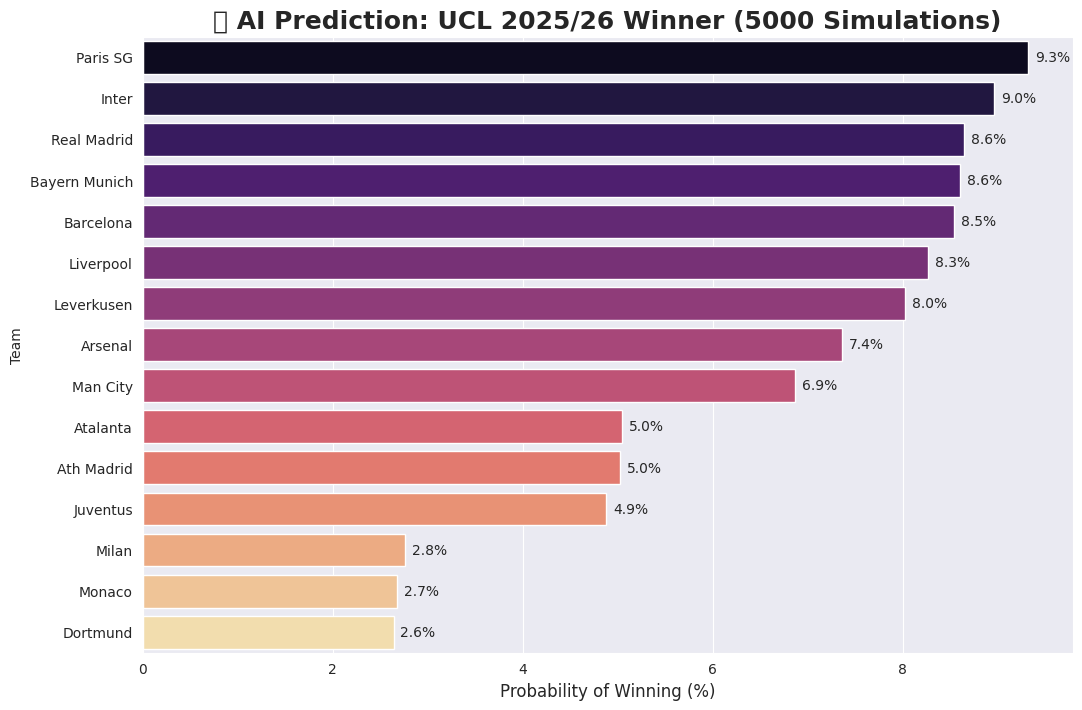

In [ ]:
N_SIMS = 5000
print(f" Simulating {N_SIMS} Tournaments... (This takes about 30-60 seconds)")

results = simulate_tournament(best_model, n_sims=N_SIMS)

# Tally Wins
win_counts = pd.Series(results).value_counts()
win_probs = (win_counts / N_SIMS * 100).reset_index()
win_probs.columns = ['Team', 'Win Probability (%)']

# Plot
plt.figure(figsize=(12, 8))
ax = sns.barplot(data=win_probs.head(15), y='Team', x='Win Probability (%)', palette='magma')
for i in ax.containers:
    ax.bar_label(i, fmt='%.1f%%', padding=5)

plt.title(f' AI Prediction: UCL 2025/26 Winner ({N_SIMS} Simulations)', fontsize=18, fontweight='bold')
plt.xlabel('Probability of Winning (%)', fontsize=12)
plt.show()